# Reorder levels per item: fixed values, tables, forecasts and custom rules

`ReorderPointPolicy` implements the periodic-review `(s,S)` and `(s,Q)` rules. At each review it compares the **inventory position** (stock on hand plus stock on order, minus backlog) with the reorder point `s`. If the position is at or below `s`, it orders up to the level `S`, or a fixed quantity `Q`.

The rule is the same for every item, but `s` and `S` usually should not be: an item that sells nine units a day needs higher levels than one that sells one. This notebook shows the ways `fit` accepts the levels and what each one records:

| Source of `s` and `S` | Argument to `fit` |
|---|---|
| one pair for all items | `reorder_point=20.0, order_up_to_level=50.0` |
| one value per item | a Series indexed by item, or a dict |
| a dated quantile forecast | `target_df` with `reorder_point_column=...` and `forecast_origin` |
| a custom rule | `target_df` with `target_provider=...` |

The last section runs all of them on the same demand and shows what per-item levels change. [Notebook 05b](05b_reorder_points_and_review_frequency.ipynb) explains how the review period sets the window a reorder point must cover. The data are synthetic: three items with Poisson demand of 9, 5 and 1.5 units per day (named espresso beans, oat milk and chai syrup).

In [1]:
import numpy as np
import pandas as pd

# Show every number with two decimals.
pd.options.display.float_format = "{:.2f}".format

## 1. Setup

Eight weeks of daily Poisson demand, drawn once with a fixed seed and replayed for every policy. The lead time is `L = 2` days and the review period `R = 3` days. The first week is a warm-up: scoring starts once the opening stock has been used up, so the opening state does not favour any policy.

In [2]:
opening_date = pd.Timestamp("2026-01-05")
rates = {"espresso_beans": 9.0, "oat_milk": 5.0, "chai_syrup": 1.5}
skus = list(rates)
lead_days, review_days = 2, 3
days, warmup_days = 56, 7

rng = np.random.default_rng(11)
dates = pd.date_range(opening_date + pd.Timedelta(days=1), periods=days, freq="D")
demand = pd.DataFrame(
    [
        {
            "unique_id": sku,
            "period": period,
            "date": date,
            "y": float(rng.poisson(rate)),
        }
        for sku, rate in rates.items()
        for period, date in enumerate(dates)
    ]
)

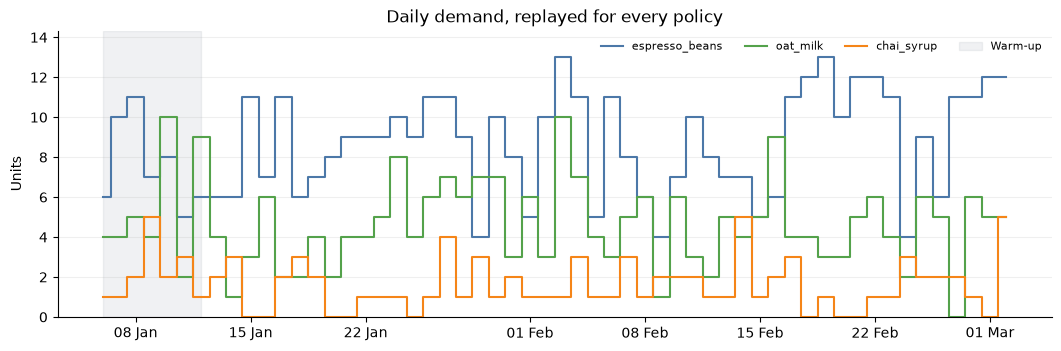

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

SKU_COLORS = ["#4C78A8", "#54A24B", "#F58518"]


def style_axis(ax):
    ax.set_ylim(0, ax.get_ylim()[1] * 1.05)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)


fig, ax = plt.subplots(figsize=(10.5, 3.4), layout="constrained")
for sku, color in zip(skus, SKU_COLORS):
    series = demand.loc[demand["unique_id"].eq(sku)]
    ax.step(series["date"], series["y"], where="mid", color=color, label=sku)
ax.axvspan(
    dates[0],
    dates[warmup_days - 1],
    color="#9CA3AF",
    alpha=0.15,
    label="Warm-up",
)
ax.set(title="Daily demand, replayed for every policy", ylabel="Units")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
style_axis(ax)
ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper right")
plt.show()

All policies start from the same opening state: stock on hand only, nothing on order. At the first review the inventory position therefore equals the stock on hand.

In [4]:
from stockcast.core import InventoryStateDataFrame

opening = InventoryStateDataFrame.from_observed(
    pd.DataFrame({"unique_id": skus, "on_hand": [40.0, 25.0, 8.0]}),
    opening_date=opening_date,
)

## 2. One pair for all items

Scalars apply the same `s` and `S` to every item. `predict()` returns the decision of one review without changing the state, which makes it a convenient way to inspect a fitted policy.

In [5]:
from stockcast.policies import ReorderPointPolicy

one_pair = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
one_pair.fit(reorder_point=20.0, order_up_to_level=50.0)

decision = one_pair.predict(opening, current_period=0).get_dataframe()
decision[
    [
        "unique_id",
        "inventory_position",
        "reorder_point",
        "target_level",
        "order_quantity",
    ]
]

,unique_id,inventory_position,reorder_point,target_level,order_quantity
0,espresso_beans,40.00,20.00,50.00,0.00
1,oat_milk,25.00,20.00,50.00,0.00
2,chai_syrup,8.00,20.00,50.00,42.00


Only chai syrup has a position at or below `s = 20`, so only chai syrup is ordered: `S − position = 50 − 8 = 42` units, about four weeks of its demand. Espresso beans, with six times the demand rate, are not ordered at a position of 40. A shared pair cannot fit items with different demand rates; section 6 measures what that costs.

## 3. One value per item

A Series indexed by item, such as a column of a planning table, gives each item its own `s` and `S`. A dict `{item: value}` works the same way. `get_parameters()` returns the fitted levels per item.

In [6]:
plan = pd.DataFrame(
    {
        "unique_id": skus,
        "s": [35.0, 20.0, 6.0],
        "S": [75.0, 45.0, 14.0],
    }
).set_index("unique_id")

planner_table = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
planner_table.fit(reorder_point=plan["s"], order_up_to_level=plan["S"])
planner_table.get_parameters()

,unique_id,reorder_point,order_up_to_level
0,espresso_beans,35.00,75.00
1,oat_milk,20.00,45.00
2,chai_syrup,6.00,14.00


`fit` validates the levels before any run: all values are finite, `s ≥ 0`, `S ≥ s`, and both name the same items. Swapped columns are refused with *order-up-to levels must be greater than or equal to reorder points*.

### `(s,Q)`: a fixed order quantity

With `order_quantity=Q` in the constructor the policy becomes `(s,Q)`: when the position is at or below `s`, it orders exactly `Q`. Only `s` is fitted.

In [7]:
lot_size = 30.0
fixed_lot = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    order_quantity=lot_size,
    allow_backorders=False,
)
fixed_lot.fit(reorder_point=plan["s"])
fixed_lot.get_parameters()

,unique_id,reorder_point,order_quantity
0,espresso_beans,35.00,30.00
1,oat_milk,20.00,30.00
2,chai_syrup,6.00,30.00


## 4. A dated quantile forecast

With a forecast, `s` has a precise meaning: the quantile, at the target service level, of demand over the **protection window** of a decision. Under periodic review, an order not placed at this review can next be placed `R` periods later and arrives `L` periods after that, so the window is `L + R = 2 + 3 = 5` days.

For Poisson demand the 5-day total is Poisson with mean `5 × rate`, so `s` is the exact 95% quantile of that distribution: the quantile of the window total, never a sum of daily quantiles. `S` adds one review period of mean demand to `s`, a planning choice rather than a quantile.

In [8]:
import math


def poisson_quantile(probability, mean):
    """Smallest k with P(N <= k) >= probability, for N ~ Poisson(mean)."""
    k, pmf = 0, math.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return float(k)


horizon = lead_days + review_days
forecast_targets = pd.DataFrame(
    {
        "unique_id": skus,
        "s_q95": [poisson_quantile(0.95, horizon * rate) for rate in rates.values()],
        "end": opening_date + pd.Timedelta(days=horizon),
    }
)
forecast_targets["S"] = forecast_targets["s_q95"] + [
    review_days * rate for rate in rates.values()
]
forecast_targets

,unique_id,s_q95,end,S
0,espresso_beans,56.00,2026-01-10,83.00
1,oat_milk,33.00,2026-01-10,48.00
2,chai_syrup,12.00,2026-01-10,16.50


A forecast target is **dated**, and the policy validates the dates:

- `forecast_origin` is the last date whose demand the forecast used;
- `freq="D"` is the length of one period;
- the date column (`end`, named with `date_column`) is the last date `s` covers. It must equal `forecast_origin` plus `L + R` periods; a target for the wrong window, for example only the two lead-time days, is refused with *target_df.end must equal 2026-01-10 00:00:00 for horizon 5*;
- `service_level=0.95` states the probability of the quantile.

The policy records this description together with its levels:

In [9]:
from_forecast = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    freq="D",
    service_level=0.95,
    allow_backorders=False,
    date_column="end",
)
from_forecast.fit(
    forecast_targets,
    reorder_point_column="s_q95",
    order_up_to_column="S",
    forecast_origin=opening_date,
)
pd.Series(from_forecast.get_target_metadata(), name="recorded").to_frame()

,recorded
representation,direct_reorder_point_target
target_probability,0.95
reorder_horizon,5
target_source,external_direct
forecast_origin,2026-01-05T00:00:00
forecast_frequency,D
reorder_end_date,2026-01-10T00:00:00
order_up_to_representation,external_policy_level


The record states that `s` is a direct quantile target at probability 0.95 over a 5-day horizon, from a forecast with origin 5 January. It is stored with every run of the policy. A forecast-based `s` that is not a quantile, for example an optimised `(s,S)` pair, uses the same call with `service_level=None`: the window is still validated, and no probability is claimed.

## 5. A custom rule: `ReorderPointTargetProvider`

A rule that computes levels from data can be packaged as a provider. `provide(target_data, sku_column=...)` receives the table passed to `fit` and returns a `ReorderPointTargets` with one row per item, `reorder_point` and `order_up_to_level`. The example is a days-of-cover rule: `s` is 4 days and `S` is 9 days of an item's recent daily demand rate, rounded up. `to_manifest()` records the rule's settings with every run.

In [10]:
from stockcast.policies import ReorderPointTargetProvider, ReorderPointTargets


class DaysOfCover(ReorderPointTargetProvider):
    """s and S as days of recent demand, rounded up to whole units."""

    def __init__(self, reorder_days, order_up_to_days):
        self.reorder_days = reorder_days
        self.order_up_to_days = order_up_to_days

    def provide(self, target_data, *, sku_column):
        rate = target_data["daily_rate"]
        levels = pd.DataFrame(
            {
                sku_column: target_data[sku_column],
                "reorder_point": np.ceil(self.reorder_days * rate),
                "order_up_to_level": np.ceil(self.order_up_to_days * rate),
            }
        )
        return ReorderPointTargets(frame=levels)

    def to_manifest(self):
        # Recorded with every run, so the rule's settings stay with the results.
        return {
            **super().to_manifest(),
            "reorder_days": self.reorder_days,
            "order_up_to_days": self.order_up_to_days,
        }

The input table holds one daily rate per item. Here the rates are given directly; in practice they would be computed from demand history. The provider's levels pass the same validation as levels given directly.

In [11]:
recent_demand = pd.DataFrame({"unique_id": skus, "daily_rate": [8.6, 5.3, 1.4]})

days_of_cover = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
days_of_cover.fit(
    recent_demand,
    target_provider=DaysOfCover(reorder_days=4, order_up_to_days=9),
)
days_of_cover.get_parameters()

,unique_id,reorder_point,order_up_to_level
0,espresso_beans,35.00,78.00
1,oat_milk,22.00,48.00
2,chai_syrup,6.00,13.00


## 6. What per-item levels change

First the levels of all five sources, read from each policy's opening decision. The `(s,Q)` policy has no `S`; its bar ends at `s + Q`, the highest position right after an order.

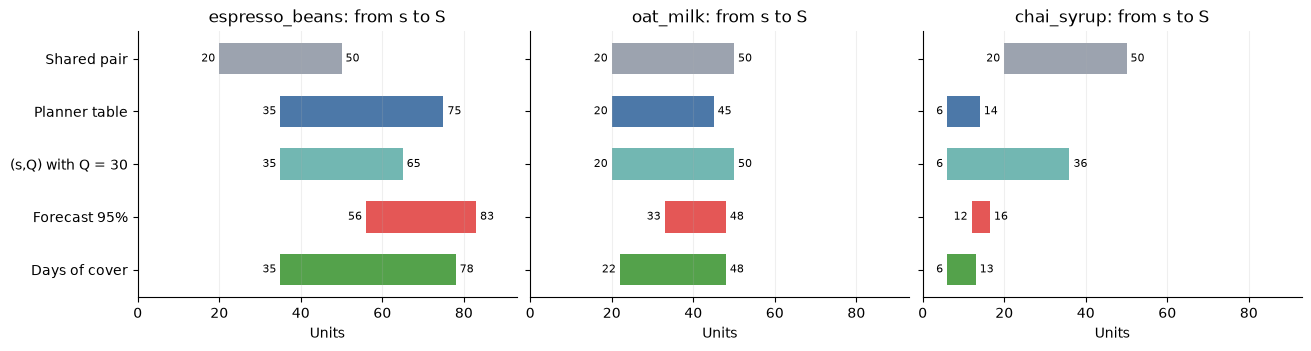

In [12]:
policies = {
    "Shared pair": one_pair,
    "Planner table": planner_table,
    "(s,Q) with Q = 30": fixed_lot,
    "Forecast 95%": from_forecast,
    "Days of cover": days_of_cover,
}
SOURCE_COLORS = ["#9CA3AF", "#4C78A8", "#72B7B2", "#E45756", "#54A24B"]

level_rows = []
for source, policy in policies.items():
    decision = policy.predict(opening, current_period=0).get_dataframe()
    # The (s,Q) policy has no S: use s + Q instead.
    top = decision["target_level"].fillna(decision["reorder_point"] + lot_size)
    level_rows.append(
        pd.DataFrame(
            {
                "source": source,
                "unique_id": decision["unique_id"],
                "s": decision["reorder_point"],
                "top": top,
            }
        )
    )
levels = pd.concat(level_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True, layout="constrained")
for ax, sku in zip(axes, skus):
    rows = levels.loc[levels["unique_id"].eq(sku)]
    ax.barh(
        rows["source"],
        rows["top"] - rows["s"],
        left=rows["s"],
        color=SOURCE_COLORS,
        height=0.6,
    )
    for y, (s, top) in enumerate(zip(rows["s"], rows["top"])):
        ax.text(s, y, f"{s:.0f} ", ha="right", va="center", fontsize=8)
        ax.text(top, y, f" {top:.0f}", ha="left", va="center", fontsize=8)
    ax.set(title=f"{sku}: from s to S", xlabel="Units")
    ax.set_xlim(0, levels["top"].max() * 1.12)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
plt.show()

**What to notice:** the shared pair is identical across items, so it is far below the other sources for the fastest item and far above them for the slowest. The forecast gives espresso beans the highest `s`, 56: a 95% quantile of five days of the highest demand rate. The planner table and days of cover are close to each other, since both scale with the demand rate.

`run_comparison({label: policy})` runs every policy on the same demand, each from its own copy of the opening state and with the same warm-up, so the levels are the only difference between the branches. Fixed levels carry no dates, so `freq="D"` gives the run its period length.

In [13]:
from stockcast.core import SimulationEngine

comparison = SimulationEngine().run_comparison(
    policies,
    demand,
    opening,
    freq="D",
    warmup_periods=warmup_days,
)

Every branch is scored with `stockcast.evaluation` using the same unit costs: holding 0.05 per unit and day, lost sales 2.00 per unit, and ordering 4.00 per order line (one item on one order).

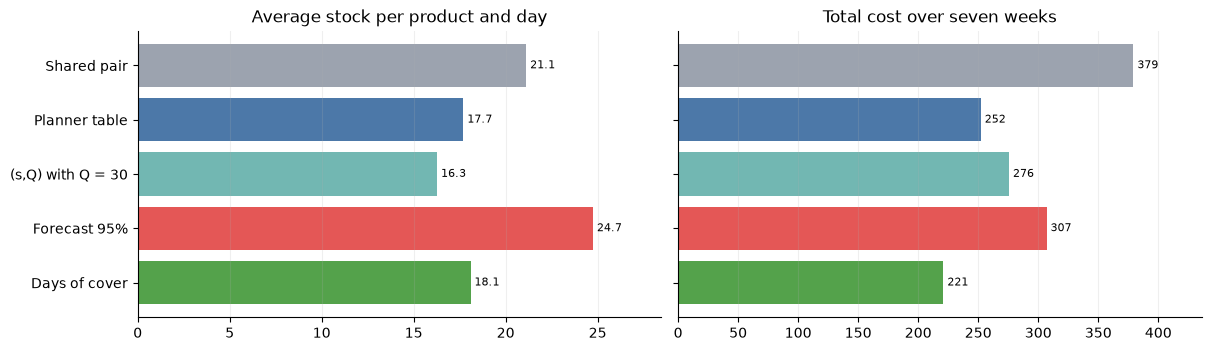

In [14]:
from stockcast.evaluation import (
    InventoryEvaluator,
    avg_on_hand,
    fill_rate,
    total_cost,
)

costs = {
    "holding_cost_per_unit_period": 0.05,
    "shortage_cost_per_unit": 2.0,
    "order_cost_per_sku_line": 4.0,
    "order_cost_per_unit": 0.0,
    "cost_components": ["holding", "shortage", "ordering"],
}
score_rows = []
for source in policies:
    evaluator = InventoryEvaluator()
    evaluator.fit(comparison[source])
    scores = evaluator.evaluate(
        [fill_rate, avg_on_hand, total_cost],
        groupby=["unique_id"],
        context=costs,
    )
    score_rows.append(scores.assign(source=source))
per_product = pd.concat(score_rows, ignore_index=True)

totals = per_product.groupby("source", sort=False).agg(
    avg_on_hand=("avg_on_hand", "mean"),
    total_cost=("total_cost", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True, layout="constrained")
for ax, column, title, label in [
    (axes[0], "avg_on_hand", "Average stock per product and day", "{:.1f}"),
    (axes[1], "total_cost", "Total cost over seven weeks", "{:.0f}"),
]:
    ax.barh(totals.index, totals[column], color=SOURCE_COLORS)
    for y, value in enumerate(totals[column]):
        ax.text(value, y, " " + label.format(value), va="center", fontsize=8)
    ax.set(title=title)
    ax.set_xlim(0, totals[column].max() * 1.15)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
plt.show()

**What to notice:** the shared pair has the highest cost, 379, although only the forecast holds more stock (24.7 units against 21.1). Days of cover has the lowest cost, 221, followed by the planner table at 252. The `(s,Q)` policy holds the least stock, 16.3, but costs more than the planner table because it loses more sales. The fill rate per item shows where each source gains or loses:

In [15]:
from IPython.display import display

# Fill rates sit close to 1, so this table shows three decimals.
fill_rates = per_product.pivot(index="source", columns="unique_id", values="fill_rate")
with pd.option_context("display.float_format", "{:.3f}".format):
    display(fill_rates.loc[list(policies), skus])

unique_id,espresso_beans,oat_milk,chai_syrup
source,,,
Shared pair,0.819,0.991,1.000
Planner table,0.970,0.986,0.987
"(s,Q) with Q = 30",0.947,0.959,0.974
Forecast 95%,1.000,1.000,0.993
Days of cover,1.000,1.000,0.974


With the shared pair, espresso beans reach a fill rate of only 0.819, while chai syrup never runs short with levels far above its demand: its cost combines shortages on one item with excess stock on another. The forecast and days of cover serve all demand for espresso beans and oat milk; days of cover does so with less stock and has occasional shortages only on chai syrup (0.974). These results belong to this demand path and these costs.

### The rule in the event table

For espresso beans under days of cover, the event table shows every review (every third day). The position before the decision (white dots) is compared with `s`; when it is at or below `s`, the order (orange) raises the position to exactly `S`. Demand then lowers the position until the next review. The code asserts both properties for every order.

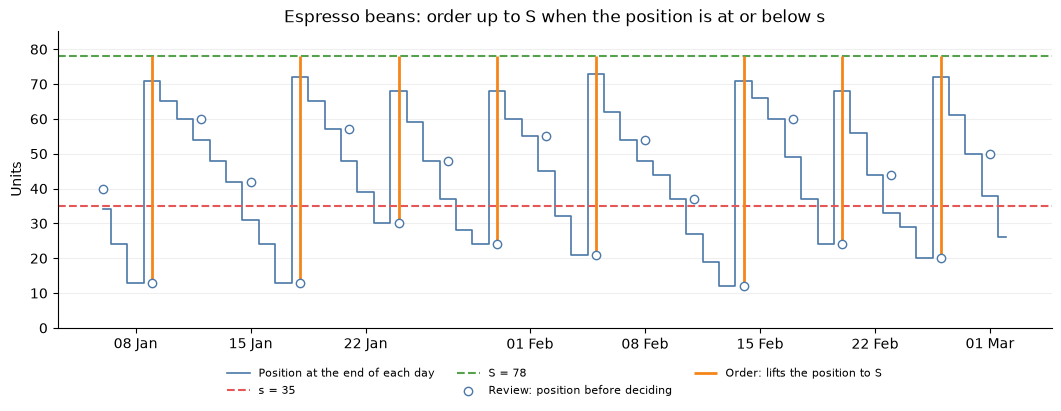

In [16]:
events = comparison["Days of cover"].to_event_frame()
beans = events.loc[
    events["event_type"].eq("period") & events["unique_id"].eq("espresso_beans")
]
beans_levels = levels.query(
    "source == 'Days of cover' and unique_id == 'espresso_beans'"
)
s, S = beans_levels["s"].item(), beans_levels["top"].item()
reviews = beans.loc[beans["is_review_period"]]
ordered = reviews.loc[reviews["order_quantity"].gt(0)]
# Every order was placed at or below s and lifted the position exactly to S.
assert (ordered["decision_inventory_position"] <= s).all()
assert np.allclose(
    ordered["decision_inventory_position"] + ordered["order_quantity"],
    S,
)

fig, ax = plt.subplots(figsize=(10.5, 4), layout="constrained")
ax.step(
    beans["date"],
    beans["inventory_position_end"],
    where="mid",
    color="#4C78A8",
    linewidth=1.2,
    label="Position at the end of each day",
)
ax.axhline(s, color="#E45756", linestyle="--", label=f"s = {s:.0f}")
ax.axhline(S, color="#54A24B", linestyle="--", label=f"S = {S:.0f}")
ax.scatter(
    reviews["date"],
    reviews["decision_inventory_position"],
    facecolor="white",
    edgecolor="#4C78A8",
    zorder=3,
    label="Review: position before deciding",
)
ax.vlines(
    ordered["date"],
    ordered["decision_inventory_position"],
    ordered["decision_inventory_position"] + ordered["order_quantity"],
    color="#F58518",
    linewidth=2,
    label="Order: lifts the position to S",
)
ax.set(
    title="Espresso beans: order up to S when the position is at or below s",
    ylabel="Units",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
style_axis(ax)
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
)
plt.show()